# Derivados Financieros 2023 - Clase 5
## Otros modelos de pricing - QuantLib

    0) PnL Explanation
    1) Montecarlo
    2) Diferencias Finitas
    3) QuantLib
    4) GUI de yapa

$$ PnL(hoy) = C(hoy)- C(ayer) = $$

$$ PnL(t=1) = C(t=1)- C(t=0) = dC(t=0) = \frac{dC}{dt}(t=0) $$

$$  \frac{dC}{dt}(t=0) =  \frac{\partial C}{\partial S}(t=0)  \frac{dS}{dt}(t=0) +  \frac{\partial C}{\partial \tau}(t=0)  \frac{d\tau}{dt}(t=0) + \frac{\partial C}{\partial \sigma}(t=0)  \frac{d\sigma}{dt}(t=0) + \frac{1}{2} \frac{\partial C}{\partial S^2}(t=0)  \left(\frac{dS}{dt}(t=0)\right)^2 \cdots $$

$$  PnL =  \frac{\partial C}{\partial S}  dS +  \frac{\partial C}{\partial \tau}  d\tau+ \frac{\partial C}{\partial \sigma}  d\sigma + \frac{1}{2} \frac{\partial C}{\partial S^2} \left(dS\right)^2 + \cdots $$


$$  PnL (hoy) =  \Delta (ayer) (S(hoy)-S(ayer)) +  \Theta(ayer)  + Vega(ayer)  (\sigma(hoy)-\sigma(ayer)) + \frac{1}{2} \Gamma  (ayer) (S(hoy)-S(ayer))^2 + \cdots $$










Este analisis nos permite por un lado verificar si nuestro modelo de precios es adecuado para el mercado y por otro, tener un control explicativo de la dinamica del precio.

Un test de PnL es un tipico ananlsis de control de riesgo. La idea es por un lado tomar 30 (u otra cantidad de dias) del pasado de datos de mercado y:

    - Por un lado calcular el PnL real, de mercado - por ejemplo call europea 


$$ C(t+1)+C(t) $$

- Por el otro con los datos de mercado de spot, volatilidad y las griegas de nuestro modelo, llegar al PnL de modelo
    - Finalemnte hacer una regrecion entre ambas
    



## Ejercicio Realizar El PnL explanation del sigueinte data historica



In [3]:
import pandas as pd
stock_data = pd.read_pickle("./stock.pkl")


option_data = pd.read_pickle("./option.pkl")

In [2]:
stock_data['day_num']=list(range(len(stock_data.index)))
stock_data



AAPL.OQ,HIGH,CLOSE,LOW,OPEN,COUNT,VOLUME,day_num
Date,,,,,,,
2020-07-01,367.36,364.11,363.91,365.01,92072.0,6988790.0,0
2020-07-02,370.46,364.11,363.77,367.88,88893.0,7383006.0,1
2020-07-06,375.77,373.85,369.87,369.95,97020.0,8166626.0,2
2020-07-07,378.60,372.69,372.23,375.54,87691.0,7127551.0,3
2020-07-08,381.47,381.37,376.42,376.92,91659.0,7538375.0,4
2020-07-09,385.27,382.73,378.70,385.00,112073.0,7596239.0,5
2020-07-10,383.88,383.68,378.85,382.03,85262.0,6229963.0,6
2020-07-13,399.82,381.91,381.04,389.06,160361.0,11564198.0,7
2020-07-14,389.00,388.23,375.53,379.50,141689.0,10757195.0,8


In [3]:

option_data['day_num']=list(range(len(option_data.index)))
option_data['vol_imp'] = 0.0

option_data


AAPLJ162041000.U,HIGH,CLOSE,LOW,OPEN,VOLUME,day_num,vol_imp
Date,,,,,,,
2020-07-01,9.22,8.45,8.25,9.12,75.0,0,0.0
2020-07-02,9.60,7.45,7.45,9.60,158.0,1,0.0
2020-07-06,9.60,9.10,8.50,9.01,404.0,2,0.0
2020-07-07,10.82,10.03,9.30,9.30,152.0,3,0.0
2020-07-08,12.45,12.45,10.50,10.50,176.0,4,0.0
2020-07-09,14.11,13.35,12.85,13.79,180.0,5,0.0
2020-07-10,14.05,14.02,12.99,14.05,19.0,6,0.0
2020-07-13,22.96,15.83,15.83,17.50,917.0,7,0.0
2020-07-14,18.00,18.00,13.25,14.60,239.0,8,0.0


In [4]:
from datetime import date
business_days = [date.date() for date in option_data.index]
business_days

[datetime.date(2020, 7, 1),
 datetime.date(2020, 7, 2),
 datetime.date(2020, 7, 6),
 datetime.date(2020, 7, 7),
 datetime.date(2020, 7, 8),
 datetime.date(2020, 7, 9),
 datetime.date(2020, 7, 10),
 datetime.date(2020, 7, 13),
 datetime.date(2020, 7, 14),
 datetime.date(2020, 7, 15),
 datetime.date(2020, 7, 16),
 datetime.date(2020, 7, 17),
 datetime.date(2020, 7, 20),
 datetime.date(2020, 7, 21),
 datetime.date(2020, 7, 22),
 datetime.date(2020, 7, 23),
 datetime.date(2020, 7, 24),
 datetime.date(2020, 7, 27),
 datetime.date(2020, 7, 28),
 datetime.date(2020, 7, 29),
 datetime.date(2020, 7, 30),
 datetime.date(2020, 7, 31)]

In [5]:

PnL_df = pd.DataFrame(index = business_days, columns = ['PnL_Mercado', 'PnL_Modelo_Explained', 'Delta', 'Theta', 'Vega','Gamma', 'PnL_Modelo_Unexplained','day_num', 'Precio_Mercado', 'Precio_Modelo','imp_vol'])
PnL_df['day_num']=list(range(len(PnL_df.index)))

PnL_df.PnL_Mercado = 0.0
PnL_df.Precio_Modelo = 0.0

PnL_df.PnL_Modelo_Explained = 0.0
PnL_df.Delta = 0.0
PnL_df.Theta = 0.0
PnL_df.Vega = 0.0
PnL_df.Gamma = 0.0
PnL_df.PnL_Modelo_Unexplained = 0.0
PnL_df.imp_vol = 0.0



PnL_df.Precio_Mercado = option_data.CLOSE

PnL_df


,PnL_Mercado,PnL_Modelo_Explained,Delta,Theta,Vega,Gamma,PnL_Modelo_Unexplained,day_num,Precio_Mercado,Precio_Modelo,imp_vol
2020-07-01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,8.45,0.0,0.0
2020-07-02,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,7.45,0.0,0.0
2020-07-06,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2,9.10,0.0,0.0
2020-07-07,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3,10.03,0.0,0.0
2020-07-08,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4,12.45,0.0,0.0
2020-07-09,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5,13.35,0.0,0.0
2020-07-10,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6,14.02,0.0,0.0
2020-07-13,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7,15.83,0.0,0.0
2020-07-14,0.0,0.0,0.0,0.0,0.0,0.0,0.0,8,18.00,0.0,0.0
2020-07-15,0.0,0.0,0.0,0.0,0.0,0.0,0.0,9,19.24,0.0,0.0


In [6]:
for i in PnL_df['day_num'].values[1:]:
    PnL_df['PnL_Mercado'].values[i] = option_data.CLOSE.values[i] - option_data.CLOSE.values[i-1]


In [7]:
PnL_df

,PnL_Mercado,PnL_Modelo_Explained,Delta,Theta,Vega,Gamma,PnL_Modelo_Unexplained,day_num,Precio_Mercado,Precio_Modelo,imp_vol
2020-07-01,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0,8.45,0.0,0.0
2020-07-02,-1.00,0.0,0.0,0.0,0.0,0.0,0.0,1,7.45,0.0,0.0
2020-07-06,1.65,0.0,0.0,0.0,0.0,0.0,0.0,2,9.10,0.0,0.0
2020-07-07,0.93,0.0,0.0,0.0,0.0,0.0,0.0,3,10.03,0.0,0.0
2020-07-08,2.42,0.0,0.0,0.0,0.0,0.0,0.0,4,12.45,0.0,0.0
2020-07-09,0.90,0.0,0.0,0.0,0.0,0.0,0.0,5,13.35,0.0,0.0
2020-07-10,0.67,0.0,0.0,0.0,0.0,0.0,0.0,6,14.02,0.0,0.0
2020-07-13,1.81,0.0,0.0,0.0,0.0,0.0,0.0,7,15.83,0.0,0.0
2020-07-14,2.17,0.0,0.0,0.0,0.0,0.0,0.0,8,18.00,0.0,0.0
2020-07-15,1.24,0.0,0.0,0.0,0.0,0.0,0.0,9,19.24,0.0,0.0


In [8]:
import datetime
r = 0.025
sigma = 0.287
K = 410
div = 0.01
tipo = "C"
expiry_datetime = datetime.date(2020,10,16)

h = 0.1
h_vol = 0.01
pasos = 250


In [4]:
import sys
sys.path.append('../..')

from Codigo.pricing import opcion_europea_bs
from Codigo.pricing import opcion_americana_bin
from Codigo.analytics import impvolfunc_bs
from Codigo.analytics import impvolfunc_bin


In [10]:
for i in PnL_df['day_num'].values:
    
    TTM = (expiry_datetime - PnL_df.index.values[i]).days
    T = TTM/365.0
    S = stock_data.CLOSE.values[i]
    
    C = opcion_europea_bs(tipo, S, K, T, r, sigma, div)
    
    
    PnL_df['Precio_Modelo'].values[i] = C
    
    
    PnL_df['imp_vol'].values[i] = impvolfunc_bs(tipo, stock_data.CLOSE.values[i], K, T, r, option_data.CLOSE.values[i] , div)
    
    sigma = PnL_df['imp_vol'].values[i]
    
    
    C_Sup = opcion_europea_bs(tipo, S + h, K, T, r, sigma, div)
    C_Sdown = opcion_europea_bs(tipo, S - h, K, T, r, sigma, div)
    
    PnL_df['Delta'].values[i] = (C_Sup - C_Sdown) / (2*h) 
    
    PnL_df['Gamma'].values[i] = (C_Sup - 2 * C + C_Sdown) / (h**2) 
    
    C_prox = opcion_europea_bs(tipo, S, K, T-1/252.0, r, sigma, div)
    
    PnL_df['Theta'].values[i] = (C_prox - C)
    

    
    C_volup = opcion_europea_bs(tipo, S, K, T, r, sigma + h_vol, div)
    C_voldown = opcion_europea_bs(tipo, S , K, T, r, sigma - h_vol, div)
    
    PnL_df['Vega'].values[i] = (C_volup - C_voldown) / (2*h_vol) 
    
    


In [11]:
PnL_df

,PnL_Mercado,PnL_Modelo_Explained,Delta,Theta,Vega,Gamma,PnL_Modelo_Unexplained,day_num,Precio_Mercado,Precio_Modelo,imp_vol
2020-07-01,0.00,0.0,0.260637,0.299910,63.919372,86.413739,0.0,0,8.45,8.017959,0.293798
2020-07-02,-1.00,0.0,0.246122,-1.031385,61.733681,-181.757184,0.0,1,7.45,8.358815,0.279288
2020-07-06,1.65,0.0,0.291661,-0.774212,67.713234,-127.706278,0.0,2,9.10,9.738564,0.269919
2020-07-07,0.93,0.0,0.300105,1.208577,68.058931,271.235183,0.0,3,10.03,8.673855,0.290105
2020-07-08,2.42,0.0,0.350517,-0.466993,73.840021,-61.375943,0.0,4,12.45,12.756912,0.285955
2020-07-09,0.90,0.0,0.362939,0.361733,74.637464,105.840319,0.0,5,13.35,12.820830,0.293059
2020-07-10,0.67,0.0,0.371622,0.265445,75.026935,87.764574,0.0,6,14.02,13.581209,0.298916
2020-07-13,1.81,0.0,0.379665,2.614389,74.027212,562.485449,0.0,7,15.83,13.017602,0.337261
2020-07-14,2.17,0.0,0.414345,-0.408785,76.624872,-40.545031,0.0,8,18.00,18.202755,0.334616
2020-07-15,1.24,0.0,0.430633,0.044558,77.362382,51.407251,0.0,9,19.24,18.982993,0.337939


In [12]:
for i in PnL_df['day_num'].values[1:]:
    #delta
    PnL_df.PnL_Modelo_Explained.values[i] = PnL_df.Delta.values[i-1] * (stock_data.CLOSE.values[i] -stock_data.CLOSE.values[i-1])#theta
    #gamma
    #PnL_df.PnL_Modelo_Explained.values[i] += 1/2* PnL_df.Gamma.values[i-1] * (stock_data.CLOSE.values[i] -stock_data.CLOSE.values[i-1])**2 #gamma
    #theta
    PnL_df.PnL_Modelo_Explained.values[i] += PnL_df.Theta.values[i-1]  
    #vega
    #PnL_df.PnL_Modelo_Explained.values[i] += PnL_df.Vega.values[i-1] * (PnL_df.imp_vol.values[i] - PnL_df.imp_vol.values[i-1])
  
    PnL_df.PnL_Modelo_Unexplained.values[i] = PnL_df.PnL_Mercado.values[i] - PnL_df.PnL_Modelo_Explained.values[i]
    
    

In [13]:
PnL_df['PnL_Modelo'] = 0.0
for i in PnL_df['day_num'].values[1:]:
    PnL_df['PnL_Modelo'].values[i] = PnL_df.Precio_Modelo.values[i]-PnL_df.Precio_Modelo.values[i-1]
PnL_df

,PnL_Mercado,PnL_Modelo_Explained,Delta,Theta,Vega,Gamma,PnL_Modelo_Unexplained,day_num,Precio_Mercado,Precio_Modelo,imp_vol,PnL_Modelo
2020-07-01,0.00,0.000000,0.260637,0.299910,63.919372,86.413739,0.000000,0,8.45,8.017959,0.293798,0.000000
2020-07-02,-1.00,0.299910,0.246122,-1.031385,61.733681,-181.757184,-1.299910,1,7.45,8.358815,0.279288,0.340855
2020-07-06,1.65,1.365843,0.291661,-0.774212,67.713234,-127.706278,0.284157,2,9.10,9.738564,0.269919,1.379749
2020-07-07,0.93,-1.112538,0.300105,1.208577,68.058931,271.235183,2.042538,3,10.03,8.673855,0.290105,-1.064709
2020-07-08,2.42,3.813491,0.350517,-0.466993,73.840021,-61.375943,-1.393491,4,12.45,12.756912,0.285955,4.083058
2020-07-09,0.90,0.009709,0.362939,0.361733,74.637464,105.840319,0.890291,5,13.35,12.820830,0.293059,0.063918
2020-07-10,0.67,0.706525,0.371622,0.265445,75.026935,87.764574,-0.036525,6,14.02,13.581209,0.298916,0.760378
2020-07-13,1.81,-0.392326,0.379665,2.614389,74.027212,562.485449,2.202326,7,15.83,13.017602,0.337261,-0.563607
2020-07-14,2.17,5.013872,0.414345,-0.408785,76.624872,-40.545031,-2.843872,8,18.00,18.202755,0.334616,5.185153
2020-07-15,1.24,0.697516,0.430633,0.044558,77.362382,51.407251,0.542484,9,19.24,18.982993,0.337939,0.780238


NameError: name 'PnL_df' is not defined

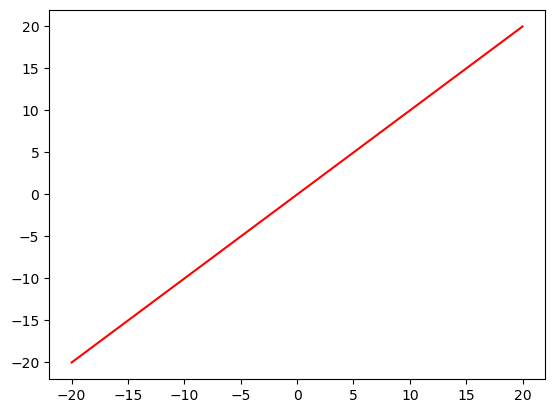

In [8]:
import numpy as np
from matplotlib import pyplot as plt
x = np.linspace(-20, 20, 1000)

plt.plot(x, x, 'r-')
plt.plot(PnL_df['PnL_Modelo'].values, PnL_df['PnL_Modelo_Explained'].values, 'o')
plt.title('PnL Attribute')
plt.xlabel('PnL Modelo')
plt.ylabel('PnL Explained Modelo')

plt.show()

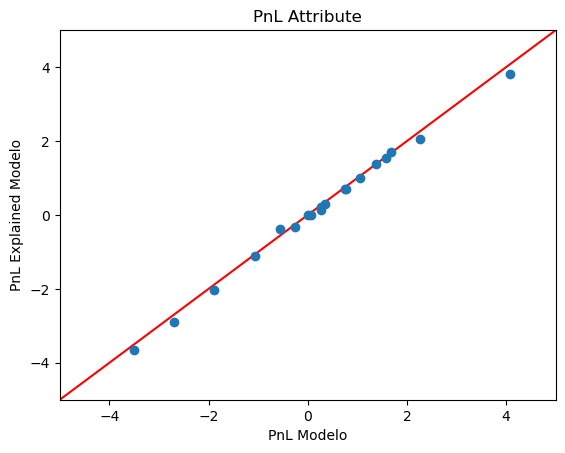

In [15]:
x = np.linspace(-20, 20, 1000)

plt.plot(x, x, 'r-')
plt.plot(PnL_df['PnL_Modelo'].values, PnL_df['PnL_Modelo_Explained'].values, 'o')
plt.title('PnL Attribute')
plt.xlabel('PnL Modelo')
plt.ylabel('PnL Explained Modelo')

plt.xlim(-5,5)
plt.ylim(-5,5)


plt.show()

## 1) Metodo de Montecarlo

In [5]:
from Codigo.pricing import opcion_europea_bs
from Codigo.pricing import opcion_europea_mc

import math

opcion_europea_mc
Def
    Calculador del precio de una opcion Europea con el modelo de MonteCarlo
Inputs
    - tipo : string - Tipo de contrato entre ["CALL","PUT"]
    - S : float - Spot price del activo
    - K : float - Strike price del contrato
    - T : float - Tiempo hasta la expiracion (en años)
    - r : float - Tasa 'libre de riesgo' (anualizada)
    - sigma : float - Volatilidad implicita (anualizada)
    - div : float - Tasa de dividendos continuos (anualizada)
    - pasos : int - Cantidad de caminos de montecarlo
Outputs
    - precio_MC: float - Precio del contrato


In [6]:
#Inicializo los parametros


tipo = "C"
S = 100
K = 100
T = 1
r = 0.05
sigma = 0.25
div = 0

In [11]:
import numpy as np
#Tomo un vector de normales aleatorias
pasos = 10
z = np.random.normal(0,1,pasos)

z



array([ 1.64198328,  0.03359347,  0.3653354 ,  0.15584598, -0.54374856,
        0.95104577,  0.43171789, -0.65034112,  0.58714359, -1.18155589])

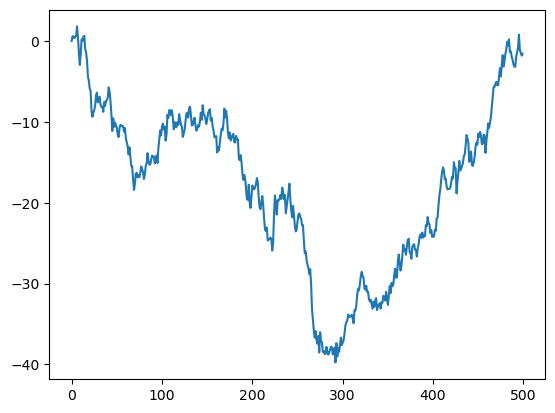

In [9]:
import matplotlib.pyplot as plt 
import math
pasos = 500
z = np.random.normal(0,1,pasos)
W=np.zeros(pasos)
W[0] = 0
for pasos in range(1,len(z)):
    W[pasos] =W[pasos-1]+z[pasos]

plt.plot(W)


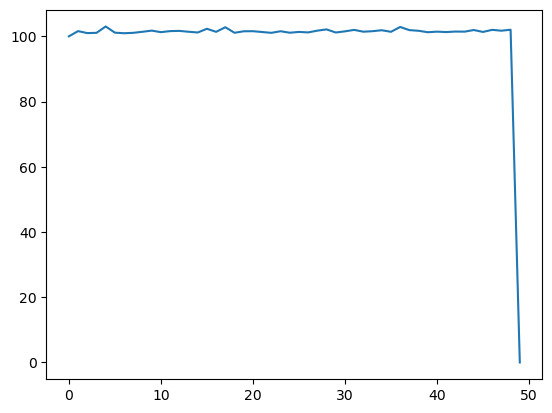

In [9]:
pasos = 50
import numpy as np
import math
z = np.random.normal(0,1,pasos)
S = np.zeros(pasos)
S[0] = 100
mu = .5
sigma = .25

for pasos in range(1,len(z)-1):
    S[pasos] =S[0]+ math.exp((mu-1/2*sigma*sigma)+sigma*z[pasos])

plt.plot(S)



Text(0, 0.5, 'Precio [USD]')

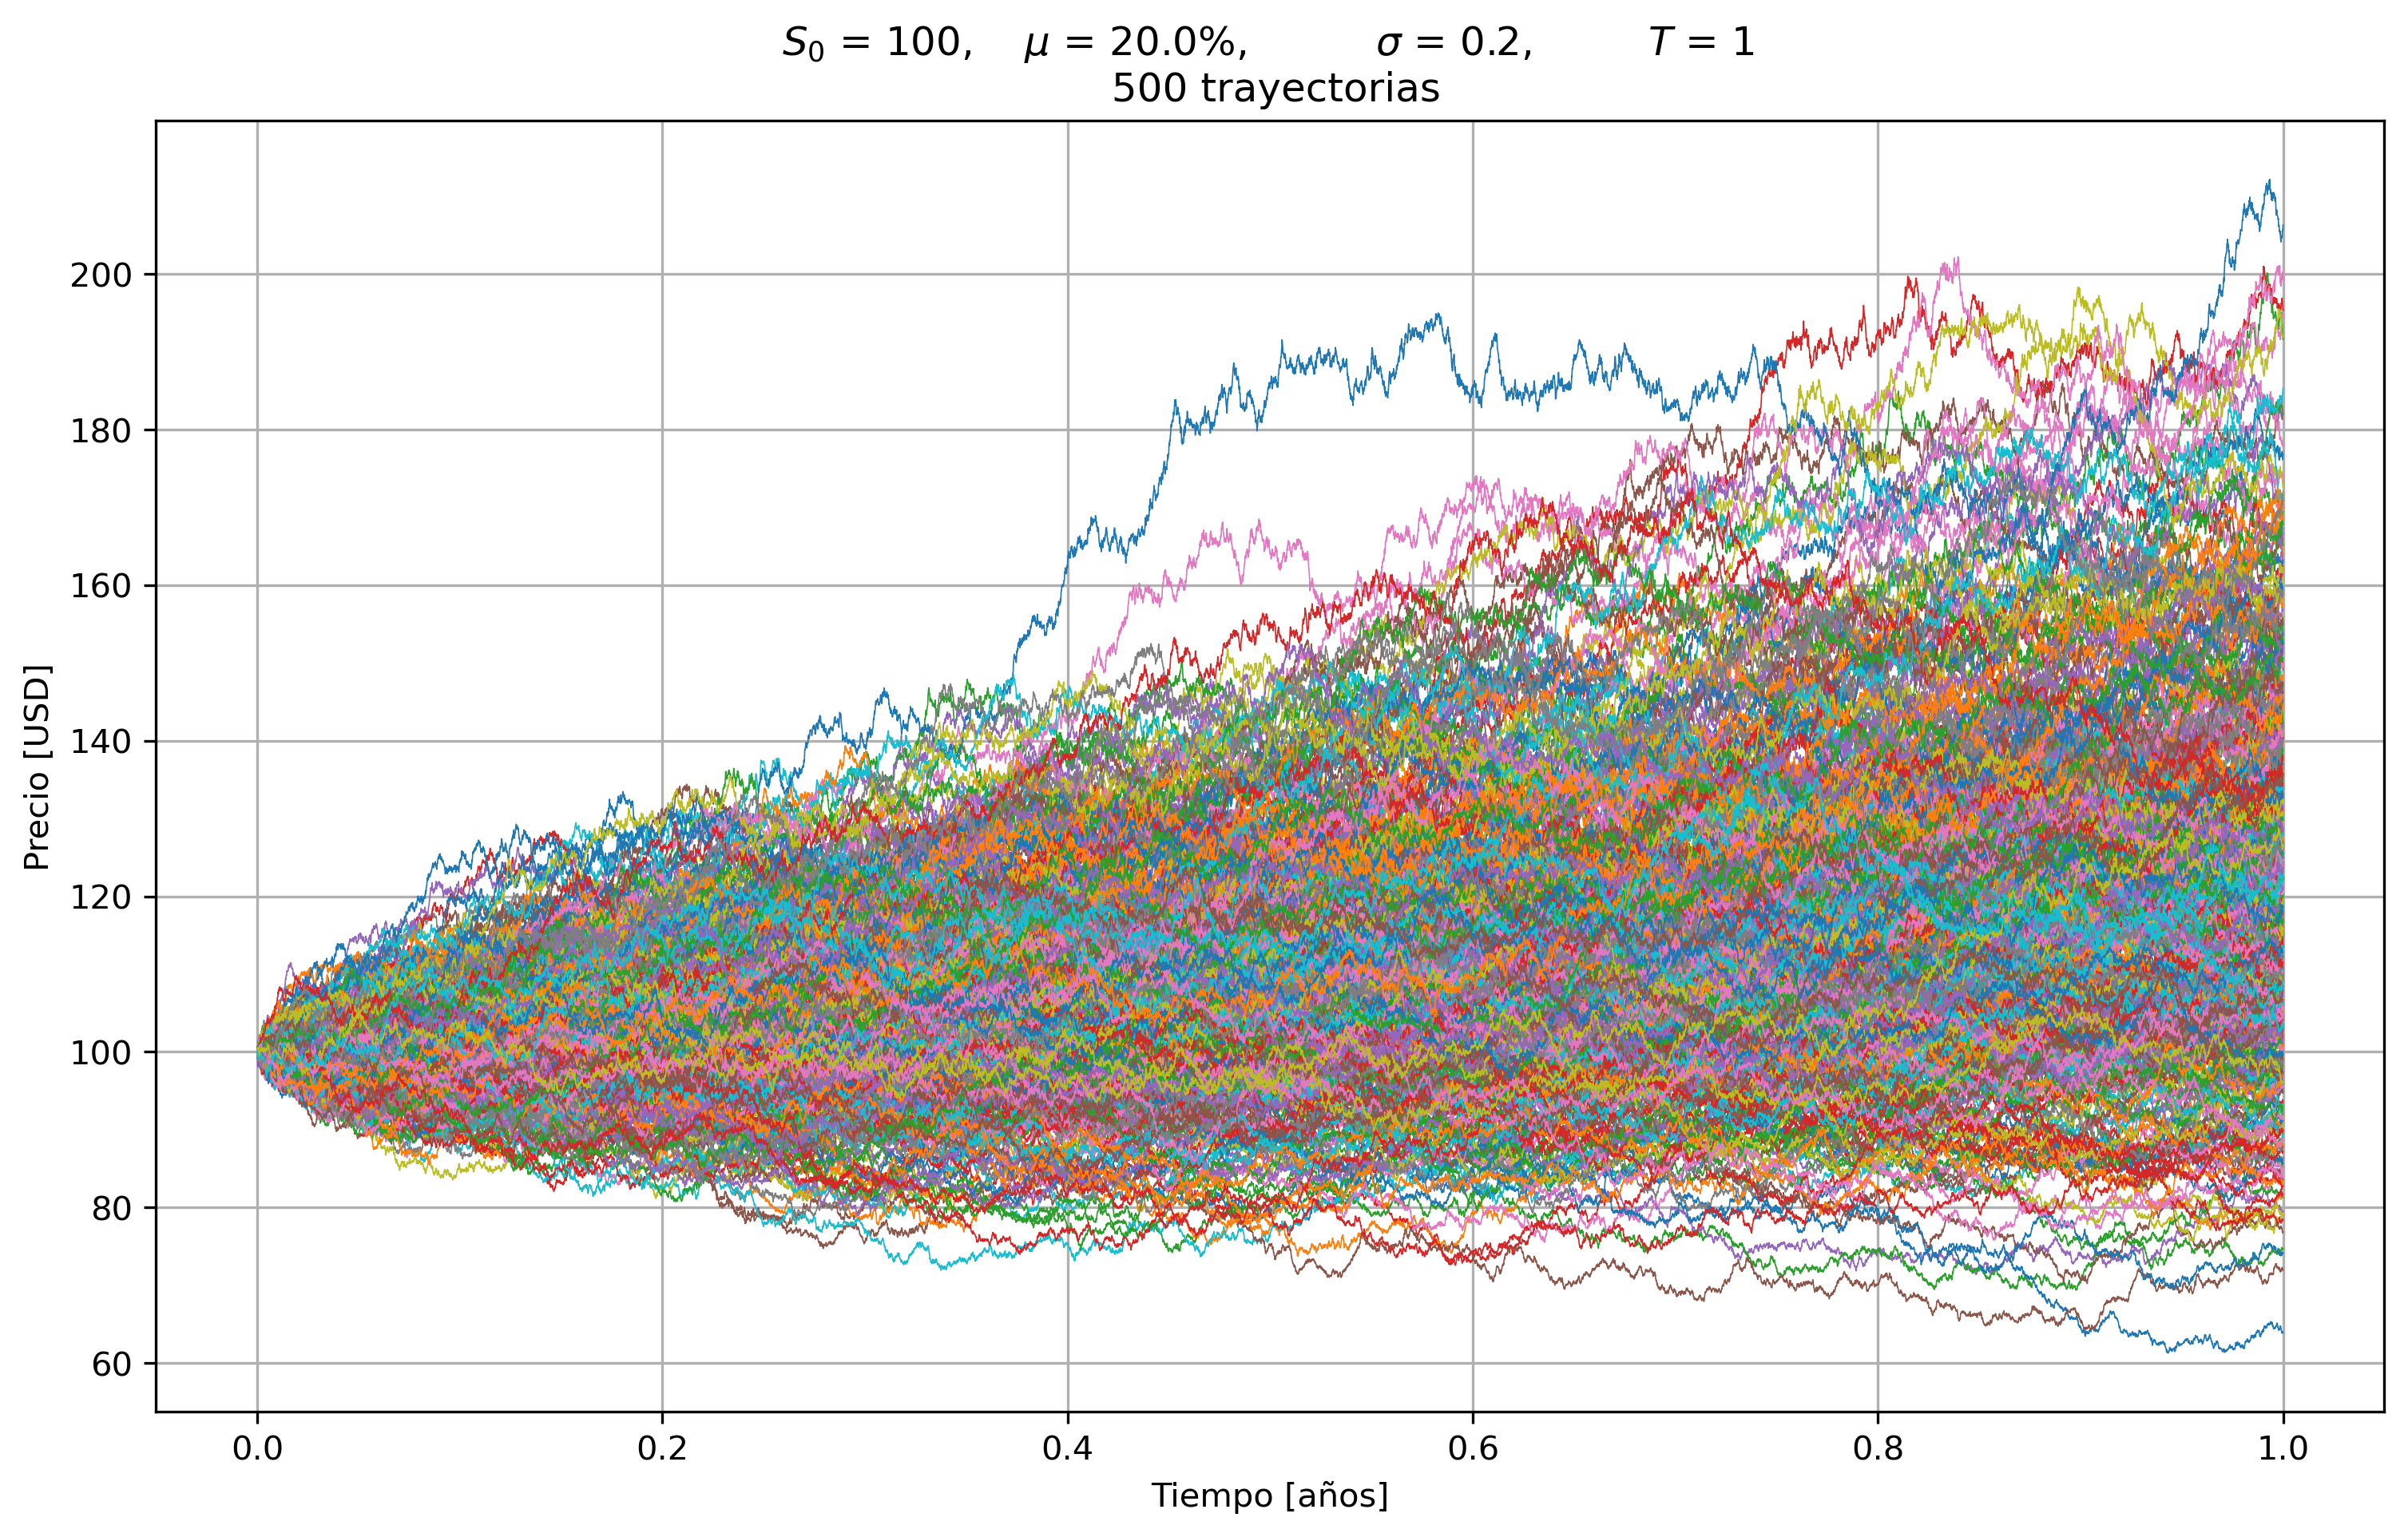

In [13]:
T = 1        # Tiempo hasta madurez de la opción (1 año)
mu = 0.2    # Tasa de crecimiento esperada del activo
sigma = 0.2 # Volatilidad del proceso
S_0 = 100      # Condición inicial (precio inicial)
dt = 0.0001  # Paso de tiempo (en la misma unidad que T).
M = 500      # Cantidad de trayectorias a simular en 1 pasada.
N = round(T/dt)
t = np.linspace(0, T, N)

# Configuración del gráfico
fig = plt.figure(figsize=(12,7), dpi = 300)
ax = fig.add_subplot()
ax.set_title(f'$ S_0$ = {S_0}, \t $\mu$ = {100*mu}%, \t $\sigma$ = {sigma}, \t $T$ = {T} \n {M} trayectorias')

# Simulación y gráfico
for _ in range(M):
    W = np.random.standard_normal(size = N) 
    W = np.cumsum(W)*np.sqrt(dt)   ### proceso de Wiener ###
    X = (mu-0.5*sigma**2)*t + sigma*W 
    S = S_0*np.exp(X)   ### movimiento Browniano geométrico ###
    ax.plot(t, S, lw = 0.4)
ax.grid(True, linestyle='-')
ax.set_xlabel('Tiempo [años]')
ax.set_ylabel('Precio [USD]')
#plt.show()


In [28]:
import numpy as np
#Tomo un vector de normales aleatorias
pasos = 500
z = np.random.normal(0,1,pasos)

z



array([-8.11081333e-01,  1.96859181e+00,  5.76729726e-01,  1.69740400e-01,
        2.31565314e-01, -5.08099145e-02, -7.51908131e-01, -7.21775820e-01,
        9.60301529e-01, -1.25052655e+00, -1.58160838e+00,  1.87151693e+00,
        1.30657287e+00,  3.88166734e-02, -1.68444569e-01, -3.41873044e-01,
       -8.78647262e-01,  1.17278997e+00, -8.50796954e-01,  2.53904475e-01,
        9.63197783e-01,  7.29220482e-01, -9.44879090e-01, -9.32727393e-01,
        1.01667413e+00,  7.54673558e-01,  1.90443377e+00,  4.14683296e-01,
        3.47563967e-01, -2.27214415e-01,  5.30881447e-01,  3.33421145e-01,
        9.39255349e-01, -9.92651973e-01, -7.80345558e-01,  1.32319593e+00,
       -1.84538699e-01,  1.86715145e-02, -1.28515534e+00,  6.30124632e-01,
       -4.82235563e-01,  4.32707936e-01, -1.37480131e-01,  9.04087607e-01,
        1.93750977e+00,  8.01537045e-01, -3.60860136e-01,  2.08156590e-01,
       -9.67048462e-01, -1.40104584e-01, -1.34420968e+00,  4.09390429e-01,
        1.29107629e-01, -

In [29]:
opcion = np.zeros(pasos) #En el ppt. C = C_i

In [30]:
for i in range(0,pasos):
    if tipo == "C":
        S_i = S * math.exp((r-div - 0.5 * math.pow(sigma,2)) * T + sigma * math.sqrt(T)  * z[i])
        payoff = max( 0 , S_i - K) # max(0,S_i-K)
    elif tipo == "P":
        payoff = max(0, K - S * math.exp((r-div - 0.5 * math.pow(sigma, 2)) * T + sigma * math.sqrt(T) * z[i]) )
    opcion[i] = math.exp(-r * T) * payoff #C_i

opcion
    

array([0.00000000e+00, 6.34267621e+01, 1.68326859e+01, 6.00184626e+00,
       7.57699567e+00, 5.77000982e-01, 0.00000000e+00, 0.00000000e+00,
       2.81000386e+01, 0.00000000e+00, 0.00000000e+00, 5.96252789e+01,
       3.92425179e+01, 2.74551972e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 3.48228883e+01, 0.00000000e+00, 8.15215786e+00,
       2.81892922e+01, 2.11831340e+01, 0.00000000e+00, 0.00000000e+00,
       2.98489334e+01, 2.19255806e+01, 6.09039886e+01, 1.23878256e+01,
       1.05988641e+01, 0.00000000e+00, 1.55567690e+01, 1.02257230e+01,
       2.74533980e+01, 0.00000000e+00, 0.00000000e+00, 3.98020709e+01,
       0.00000000e+00, 2.25386489e+00, 0.00000000e+00, 1.83371701e+01,
       0.00000000e+00, 1.28733794e+01, 0.00000000e+00, 2.63804383e+01,
       6.21995246e+01, 2.33049706e+01, 0.00000000e+00, 6.97773227e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 1.22456596e+01,
       4.97980103e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
      

In [31]:
precio_MC = np.mean(opcion)

precio_MC

desvio = math.sqrt(np.var(opcion)/pasos)

print("precio",precio_MC)


print("desvio", desvio)

print("Black Scholes", opcion_europea_bs(tipo, S, K, T, r, sigma, div))

precio 12.466862322462138
desvio 0.787267610249338
Black Scholes 12.335998930368717


### Convergencia del metodo

In [35]:
tipo = "C"
S = 100
K = 100
T = 1
r = 0.05
sigma= 0.25
div =0.0

pasos_vec = [1,2,3,4,5,6,7,8,9,10,12,14,16,18,20,25,30,400,500,750,1000,1250,1500,2000,2500,3000, 5000, 50000, 100000]      
precios = np.zeros(len(pasos_vec))

for index in range(len(pasos_vec)):
    precios[index] = opcion_europea_mc(tipo, S, K, T, r, sigma, div, pasos_vec[index])
 
precio_BS = opcion_europea_bs(tipo, S, K, T, r, sigma, div)

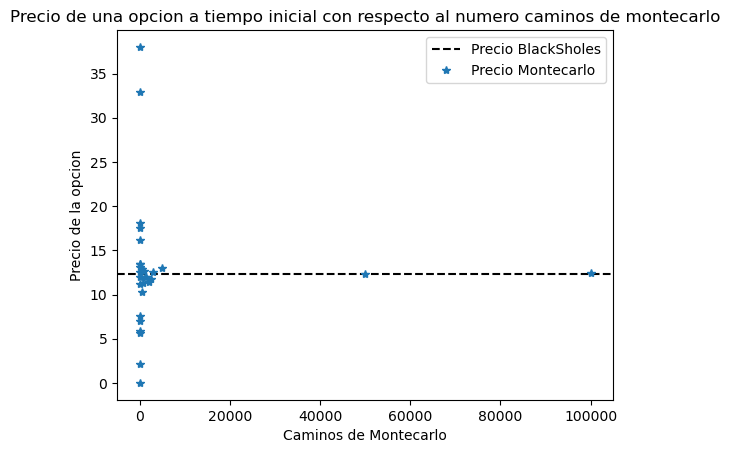

In [36]:
from matplotlib import pyplot as plt
plt.axhline(y=precio_BS, color = 'black', linestyle='--', label='Precio BlackSholes')
plt.plot(pasos_vec,precios,'*', label='Precio Montecarlo')

plt.legend()

plt.xlabel('Caminos de Montecarlo')
plt.ylabel('Precio de la opcion')
plt.title('Precio de una opcion a tiempo inicial con respecto al numero caminos de montecarlo')

plt.show()

In [50]:
print(precio_BS, precios)



12.335998930368717 [ 0.          0.         26.57838215 28.39193324  8.67127044 16.53404634
 15.24991088  7.68217573 13.15572537 17.25801073 18.72142902 13.5735907
  7.97974177  8.43678015 19.22803589 15.49666018 18.01418196  8.78277884
 12.7768791   8.78788759 14.22261709 12.15193487 11.40344473 11.42876401
 13.32973828 11.58789789 13.06075105 12.15358413 12.32867882]


# 2) Metodo de diferencias finitas

In [51]:
from Codigo.pricing import opcion_americana_fd
from Codigo.pricing import opcion_europea_fd

from scipy.interpolate import interp1d

opcion_europea_fd
Def
    Calculador del precio de una opcion Europea con el modelo de Diferencias Finitas (metodo explicito)
Inputs
    - tipo : string - Tipo de contrato entre ["CALL","PUT"]
    - S : float - Spot price del activo
    - K : float - Strike price del contrato
    - T : float - Tiempo hasta la expiracion (en años)
    - r : float - Tasa 'libre de riesgo' (anualizada)
    - sigma : float - Volatilidad implicita (anualizada)
    - div : float - Tasa de dividendos continuos (anualizada)
Outputs
    - precio_FD: float - Precio del contrato

In [52]:
tipo = "C"
S = 100
K = 100
T = 1
r = 0.05
sigma= 0.25
div =0.0

In [53]:
#Hadrcode de la grilla de diferencias finitas
M = 160
N = 1600

#M = 6
#N = 4


dS = 2 * S / M
dt = T / N

In [54]:
# Grilla de spots y tiempos
S_vec = np.linspace(0, 2*S, M+1)
t_vec = np.linspace(0, T, N+1)



In [55]:
# Armado de la matriz tridiagonal
j = np.arange(1,M)
j2 = np.zeros(M-1)
aj = np.zeros(M-1)
bj = np.zeros(M-1)
cj = np.zeros(M-1)

for index in range(0,M-1):
    sigma2 = sigma*sigma
    j2[index] = j[index] * j[index]
    aj[index] = 0.5 * dt * (sigma2 * j2[index]- (r-div) * j[index])
    bj[index] = 1-dt * (sigma2 * j2[index] + r)
    cj[index] = 0.5 * dt * (sigma2 * j2[index] + (r-div) * j[index])

In [56]:
# Matriz tridiagonal

A = np.diag(bj)
for index in range(0, M - 2):
    A[index + 1, index] = aj[index + 1]  # terms below the diagonal
    A[index, index + 1] = cj[index]  # terms above the diagonal
    


In [57]:
# Matriz de precios de la opcion
opcion_precios = np.zeros((M+1,N+1)) #V

In [58]:
#Condiciones de contorno

# Condicion final - Payoff

if tipo == "C":
    opcion_precios[:,-1] = np.maximum(S_vec - K, 0)
elif tipo == "P":
    opcion_precios[:,-1] = np.maximum(K - S_vec, 0)

In [59]:
# Casos limite en S=0 y S~inf

if tipo == "C":
    opcion_precios[0, :] = 0
    opcion_precios[-1, :] = S_vec[-1]*np.exp(-div*np.flip(t_vec)) - K * np.exp(-r*np.flip(t_vec))
elif tipo == "P":
    opcion_precios[0, :] = K * np.exp(-r * np.flip(t_vec))
    opcion_precios[-1, :] = 0 #K * np.exp(-r * np.flip(t_vec))

In [60]:
    
# Calculo en el interior
# variable auxiliar para sumar en la primer y ultimo fila
constantes_bordes = np.array((aj[0], cj[-1]))
for i in list(reversed(range(0,N))):

    opcion_precios[1:M,i] = A @ opcion_precios[1:M,i+1]
    #Offset the first and last terms
    opcion_precios[[1,M-1],i] = opcion_precios[[1,M-1],i] + constantes_bordes * opcion_precios[[0, M],i+1];

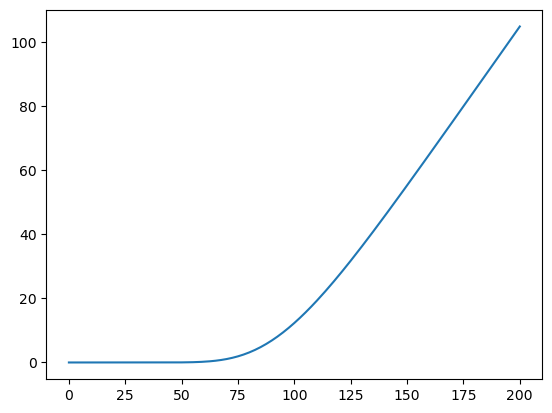

In [61]:
from matplotlib import pyplot as plt

plt.plot(S_vec,opcion_precios[:,0])

plt.show()

In [62]:
#En este punto ya esta TODA la grilla, ahora calculo lo requerido

f = interp1d(S_vec,opcion_precios[:,0])

S=100
precio_FD = float(f(S))




precio_FD


12.33380258723264

In [63]:
from mpl_toolkits import mplot3d

X, Y = np.meshgrid(t_vec, S_vec)
Z = opcion_precios

In [64]:
print('X', np.shape(X))
print('Y', np.shape(Y))
print('Z', np.shape(Z))

X (161, 1601)
Y (161, 1601)
Z (161, 1601)


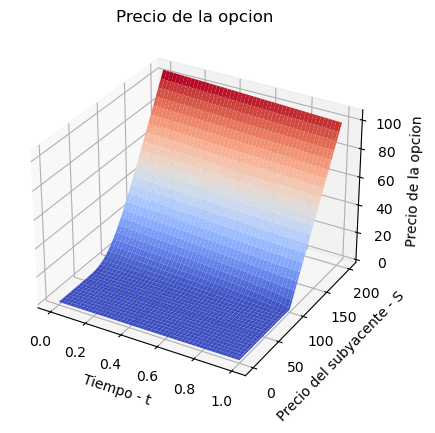

In [65]:
fig = plt.figure()

ax = plt.axes(projection='3d')
ax.plot_surface(X, Y, Z, cmap='coolwarm')#, edgecolor='none')#rstride=1, cstride=1,
                

ax.set_title('Precio de la opcion');
ax.set_xlabel('Tiempo - t')
ax.set_ylabel('Precio del subyacente - S')
ax.set_zlabel('Precio de la opcion')

plt.show()

# 3) QuantLib o Introduccion a una Verdadera plataforma de pricing/riesgo

In [37]:
pip install QuantLib

Note: you may need to restart the kernel to use updated packages.


In [38]:
from Codigo.utils import *
import QuantLib as ql

### Opciones

### Supongamos una opcion de AAPL con precio strike de 450 expirando el 16 de octubre de 2020. Supongamos que el spot es 440. La vol implicita es sabida que es 31%, y tiene un dividendo de 0.75%. Valuemos la opcion al dia de hoy (10 de Agosto 2020)

#### Definimos los inputs

In [39]:
S = 456.30
K = 460
sigma = 0.3394 # the historical vols for a year
div =  0.075
r = 0.0013

option_type = ql.Option.Call

option_type

1

#### Para las fechas QuantLib es mas preciso. Pide convenciones y calendarios

In [40]:
maturity_date = ql.Date(16, 10, 2020)
calculation_date = ql.Date(6, 8, 2020)

day_count = ql.Actual365Fixed()


ql.Argentina()
calendar = ql.UnitedStates(ql.UnitedStates.NYSE)

ql.UnitedStates
ql.Settings.instance().evaluationDate = calculation_date

maturity_date

Date(16,10,2020)

#### Aqui construimos a la opcion europea

In [41]:
payoff = ql.PlainVanillaPayoff(option_type, K)

exercise = ql.EuropeanExercise(maturity_date)
european_option = ql.VanillaOption(payoff, exercise)



#### Aca constuimos el proceso de Black Sholes Merton

##### El objeto spot

In [43]:
spot_obj = ql.QuoteHandle(ql.SimpleQuote(S))

spot_obj

<QuantLib.QuantLib.QuoteHandle; proxy of <Swig Object of type 'Handle< Quote > *' at 0x000002D36C53C990> >

In [44]:
spot_obj.value()

456.3

##### El objeto curva de descuento (flat en este caso, constante)

In [45]:
rate_obj = ql.YieldTermStructureHandle(ql.FlatForward(calculation_date, 
                                                            r, 
                                                    day_count))

##### El objeto curva de dividendos (flat en este caso, constante)

In [46]:
dividend_obj = ql.YieldTermStructureHandle(ql.FlatForward(calculation_date, 
                                                      div, 
                                                      day_count))

##### El objeto volatilidad (flat en este caso, constante)

In [47]:
vol_obj = ql.BlackVolTermStructureHandle(ql.BlackConstantVol(calculation_date, 
                                                                 calendar, 
                                                                 sigma, 
                                                             day_count))

In [76]:
##### El proceso propiamente dicho

In [48]:
bsm_process = ql.BlackScholesMertonProcess(spot_obj, 
                                        dividend_obj, 
                                        rate_obj, 
                                        vol_obj)

## Modelos de precio

###  `AnalyticEuropeanEngine` (Black Scholes)

In [50]:
european_option.setPricingEngine(ql.AnalyticEuropeanEngine(bsm_process))

bs_price = european_option.NPV()
print("El precio teorico usando el modelo de BS es: ", bs_price)

El precio teorico usando el modelo de BS es:  22.340433141477693


###  `FdBlackScholesVanillaEngine` (Diferencias Finitas)

In [52]:
european_option.setPricingEngine(ql.FdBlackScholesVanillaEngine(bsm_process))

fd_price = european_option.NPV()
print("El precio teorico usando el modelo de Dif. Finitas es: ", fd_price)

El precio teorico usando el modelo de Dif. Finitas es:  22.350547133690334


###  `MCEuropeanEngine` (Montecarlo)

In [53]:
european_option.setPricingEngine(ql.MCEuropeanEngine(bsm_process, "PseudoRandom", timeSteps=20, requiredSamples=500000))

mc_price = european_option.NPV()
print("El precio teorico usando el modelo de MonteCarlo es: ",  mc_price)

El precio teorico usando el modelo de MonteCarlo es:  22.294812708018718


In [54]:
european_option.errorEstimate()

0.05588091625963728

###  `BinomialVanillaEngine` (Binomial)

In [55]:
european_option.setPricingEngine(ql.BinomialVanillaEngine(bsm_process, "crr", 1000))

bin_price = european_option.NPV()
print("El precio teorico usando el modelo Binomial es: ",  bin_price)

El precio teorico usando el modelo Binomial es:  22.340372556198265


# Comparacion de TODOS* los modelos vistos (caso de juguete)

### Fijo los parametros

In [56]:
S = 100
K = 100
sigma = 0.25 # the historical vols for a year
div =  0.0
r = 0.05

tipo = 'C'

option_type = ql.Option.Call

maturity_date = ql.Date(10, 8, 2021)
calculation_date = ql.Date(10, 8, 2020)
day_count = ql.Actual365Fixed()
nyse = ql.UnitedStates.NYSE

calendar = ql.UnitedStates(nyse)
ql.Settings.instance().evaluationDate = calculation_date

T = 1



## Pricers vistos en clase

### Importo los pricers vistos en clase

In [57]:
from Codigo.pricing import opcion_europea_bs
from Codigo.pricing import opcion_europea_mc
from Codigo.pricing import opcion_europea_fd
from Codigo.pricing import opcion_europea_bin

import timeit

### Corro cada uno de los pricers (les tomo el tiempo de ejecucion tambien)

In [58]:
start = timeit.default_timer()
precio_bs = opcion_europea_bs(tipo, S, K, T, r, sigma, div)
end = timeit.default_timer()
tiempo_bs = end - start


start = timeit.default_timer()
precio_bin = opcion_europea_bin(tipo, S, K, T, r, sigma, div, 5000)
end = timeit.default_timer()
tiempo_bin = end - start

start = timeit.default_timer()
precio_mc = opcion_europea_mc(tipo, S, K, T, r, sigma, div, 5000)
end = timeit.default_timer()
tiempo_mc = end - start

start = timeit.default_timer()
precio_fd = opcion_europea_fd(tipo, S, K, T, r, sigma, div)
end = timeit.default_timer()
tiempo_fd = end - start

## Precios QuantLib

### Seteo lo necesario en QuantLib

In [59]:
payoff = ql.PlainVanillaPayoff(option_type, K)
exercise = ql.EuropeanExercise(maturity_date)
european_option = ql.VanillaOption(payoff, exercise)

spot_obj = ql.QuoteHandle(ql.SimpleQuote(S))

rate_obj = ql.YieldTermStructureHandle(ql.FlatForward(calculation_date, 
                                                            r, 
                                                    day_count))

dividend_obj = ql.YieldTermStructureHandle(ql.FlatForward(calculation_date, 
                                                      div, 
                                                      day_count))

vol_obj = ql.BlackVolTermStructureHandle(ql.BlackConstantVol(calculation_date, 
                                                                 calendar, 
                                                                 sigma, 
                                                             day_count))

bsm_process = ql.BlackScholesMertonProcess(spot_obj, 
                                        dividend_obj, 
                                        rate_obj, 
                                        vol_obj)



### Corro cada uno de los pricers (les tomo el tiempo de ejecucion tambien)

In [60]:

start = timeit.default_timer()
european_option.setPricingEngine(ql.AnalyticEuropeanEngine(bsm_process))
bs_price = european_option.NPV()
end = timeit.default_timer()
time_bs = end - start

start = timeit.default_timer()
european_option.setPricingEngine(ql.FdBlackScholesVanillaEngine(bsm_process))
fd_price = european_option.NPV()
end = timeit.default_timer()
time_fd = end - start

start = timeit.default_timer()
european_option.setPricingEngine(ql.MCEuropeanEngine(bsm_process, "PseudoRandom", timeSteps=20, requiredSamples=5000))
mc_price = european_option.NPV()
end = timeit.default_timer()
time_mc = end - start

start = timeit.default_timer()
european_option.setPricingEngine(ql.BinomialVanillaEngine(bsm_process, "crr", 5000))
bin_price = european_option.NPV()
end = timeit.default_timer()
time_bin = end - start



### Imprimo TODO

In [61]:
print("Precio modelo Europea BS visto en clase:", precio_bs)
print("Tiempo modelo Europea BS visto en clase:", tiempo_bs)

print("Precio modelo Europea Binomial visto en clase:", precio_bin)
print("Tiempo modelo Europea Binomial visto en clase:", tiempo_bin)

print("Precio modelo Europea Montecarlo visto en clase:", precio_mc)
print("Tiempo modelo Europea Montecarlo visto en clase:", tiempo_mc)

print("Precio modelo Europea Dif. Finitas visto en clase:", precio_fd)
print("Tiempo modelo Europea Dif. Finitas visto en clase:", tiempo_fd)


print("Precio modelo Europea BS QuantLib", bs_price)
print("Tiempo modelo Europea BS QuantLib:", time_bs)

print("Precio modelo Europea Binomial QuantLib:", bin_price)
print("Tiempo modelo Europea Binomial QuantLib:", time_bin)

print("Precio modelo Europea Montecarlo QuantLib:", mc_price)
print("Tiempo modelo Europea Montecarlo QuantLib:", time_mc)

print("Precio modelo Europea Dif. Finitas QuantLib:", fd_price)
print("Tiempo modelo Europea Dif. Finitas QuantLib:", time_fd)

Precio modelo Europea BS visto en clase: 12.335998930368717
Tiempo modelo Europea BS visto en clase: 0.0007663000014872523
Precio modelo Europea Binomial visto en clase: 12.33550453323051
Tiempo modelo Europea Binomial visto en clase: 48.09737329999916
Precio modelo Europea Montecarlo visto en clase: 12.540907126257983
Tiempo modelo Europea Montecarlo visto en clase: 0.011395300000003772
Precio modelo Europea Dif. Finitas visto en clase: 12.326737692416552
Tiempo modelo Europea Dif. Finitas visto en clase: 0.2730627999990247
Precio modelo Europea BS QuantLib 12.335998930368715
Tiempo modelo Europea BS QuantLib: 0.0002657999993971316
Precio modelo Europea Binomial QuantLib: 12.335493341380698
Tiempo modelo Europea Binomial QuantLib: 0.17177739999897312
Precio modelo Europea Montecarlo QuantLib: 12.734245574546776
Tiempo modelo Europea Montecarlo QuantLib: 0.09118889999990643
Precio modelo Europea Dif. Finitas QuantLib: 12.343995594762795
Tiempo modelo Europea Dif. Finitas QuantLib: 0.00

### Tabla de precios por modelo [NO ACTUALIZADA]

| Precio | Clase | QuantLib |
| --- | --- | --- |
| BS | 12.336 | 12.336 |
| Binomial | 12.33355 | 12.33347 |
| Montecarlo | _12.33747_ | _12.38694_ |
| Dif.Finitas | 12.33380 | 12.34399 |

### Tabla de tiempos de ejecucion por modelo**

| Tiempo | Clase | QuantLib |
| --- | --- | --- |
| BS | **0.00033** | **0.00023** |
| Binomial | 17.38176 | **0.06012** |
| Montecarlo | **0.72694** | 3.03739 |
| Dif.Finitas | 0.046359 | **0.001721** |

### Opciones Americanas


In [89]:
S = 100
K = 100
sigma = 0.25 # the historical vols for a year
div =  0.0
r = 0.05
tipo = 'C'

option_type = ql.Option.Put

maturity_date = ql.Date(10, 8, 2021)
calculation_date = ql.Date(10, 8, 2020)
day_count = ql.Actual365Fixed()
calendar = ql.UnitedStates(nyse)
ql.Settings.instance().evaluationDate = calculation_date

T = 1


In [90]:
payoff = ql.PlainVanillaPayoff(option_type, K)

am_exercise = ql.AmericanExercise(calculation_date, maturity_date)
american_option = ql.VanillaOption(payoff, am_exercise)

In [91]:
spot_obj = ql.QuoteHandle(ql.SimpleQuote(S))

rate_obj = ql.YieldTermStructureHandle(ql.FlatForward(calculation_date, 
                                                            r, 
                                                    day_count))

dividend_obj = ql.YieldTermStructureHandle(ql.FlatForward(calculation_date, 
                                                      div, 
                                                      day_count))

vol_obj = ql.BlackVolTermStructureHandle(ql.BlackConstantVol(calculation_date, 
                                                                 calendar, 
                                                                 sigma, 
                                                             day_count))

bsm_process = ql.BlackScholesMertonProcess(spot_obj, 
                                        dividend_obj, 
                                        rate_obj, 
                                        vol_obj)

In [92]:
# No hay Black Scholes
american_option.setPricingEngine(ql.BinomialVanillaEngine(bsm_process, "crr", 1000))
bin_price_ame = american_option.NPV()

american_option.setPricingEngine(ql.FdBlackScholesVanillaEngine(bsm_process))
fd_price_ame = american_option.NPV()

american_option.setPricingEngine(ql.MCAmericanEngine(bsm_process, "PseudoRandom", timeSteps=20, requiredSamples=500000))
mc_price_ame = american_option.NPV()



In [93]:
american_option.setPricingEngine(ql.AnalyticEuropeanEngine(bsm_process))
bin_price_ame = american_option.NPV()

RuntimeError: not an European option

In [94]:
from Codigo.pricing import opcion_americana_bin
from Codigo.pricing import opcion_americana_fd

In [95]:
tipo = "P"
precio_bin_ame = opcion_americana_bin(tipo, S, K, T, r, sigma, div, 1000)
precio_fd_ame = opcion_americana_fd(tipo, S, K, T, r, sigma, div)


In [96]:
print("Precio modelo Amercana Binomial visto en clase:", precio_bin_ame)
print("Precio modelo Amercana Dif. Finitas visto en clase:", precio_fd_ame)

print("Precio modelo Amercana Binomial QuantLib:", bin_price_ame)
print("Precio modelo Amercana Montecarlo QuantLib:", mc_price_ame)
print("Precio modelo Amercana Dif. FinitasQuantLib:", fd_price_ame)

Precio modelo Amercana Binomial visto en clase: 7.973040110898395
Precio modelo Amercana Dif. Finitas visto en clase: 8.076404881004946
Precio modelo Amercana Binomial QuantLib: 7.973463892545318
Precio modelo Amercana Montecarlo QuantLib: 7.841711565499307
Precio modelo Amercana Dif. FinitasQuantLib: 7.966283110785785
